In [ ]:
 # gender age 공분산 통해서 회귀분석 돌린다..?
 # 두개의 영향을 보고싶지 않을 때

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

In [ ]:
data = pd.read_csv("healthcare-dataset-stroke-data.csv") # 데이터 불러오기
data.head() # 데이터 위에서 5개만 보기

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
column_unique = ['gender', 'hypertension', 'heart_disease',  # unique 값을 보고싶은 열만 변수에 저장
                 'ever_married','work_type', 'Residence_type', 
                 'smoking_status', 'stroke']

In [ ]:
for i in column_unique: # 각 행별로 어떤 값들이 있는지 
    a = data[i].unique()
    print(a)

['Male' 'Female' 'Other']
[0 1]
[1 0]
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
['Urban' 'Rural']
['formerly smoked' 'never smoked' 'smokes' 'Unknown']
[1 0]


In [ ]:
data.info() # 결측값 확인 / age 실수인것 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# 전처리

## 이상치 
- gender

In [ ]:
data["gender"].value_counts() #  한 개밖에 없어서 제거 결정

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [ ]:
data.loc[data["gender"] == "Other"].index

Int64Index([3116], dtype='int64')

In [ ]:
data = data.drop(data.loc[data["gender"] == "Other"].index, axis=0).copy() # Other 행 삭제

In [ ]:
data["gender"].value_counts() # 지워졌나 확인

Female    2994
Male      2115
Name: gender, dtype: int64

## 결측값
- 흡연 컬럼의 unkown
- bmi 결측값

In [ ]:
data["smoking_status"].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: smoking_status, dtype: int64

In [ ]:
1544/(1892+884+789) * 100 # 결측값 비율 43%

43.30995792426368

In [ ]:
data = data.drop(data.loc[data["smoking_status"]=="Unknown"].index, axis = 0).copy() # Unkown이 있는 행 모두 삭제

In [ ]:
data["smoking_status"].value_counts()

never smoked       1892
formerly smoked     884
smokes              789
Name: smoking_status, dtype: int64

In [ ]:
data = data.loc[~data["bmi"].isna()] # bmi가 결측값이 아닌 행들만 가져옴

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3425 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3425 non-null   int64  
 1   gender             3425 non-null   object 
 2   age                3425 non-null   float64
 3   hypertension       3425 non-null   int64  
 4   heart_disease      3425 non-null   int64  
 5   ever_married       3425 non-null   object 
 6   work_type          3425 non-null   object 
 7   Residence_type     3425 non-null   object 
 8   avg_glucose_level  3425 non-null   float64
 9   bmi                3425 non-null   float64
 10  smoking_status     3425 non-null   object 
 11  stroke             3425 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 347.9+ KB


## 자료형 변경
- age 실수 -> 정수

In [ ]:
data = data.astype({"age":int})

In [ ]:
data["age"].dtype

dtype('int64')

## 이진화 / 더미변수
- gender
- ever_married
- Residence_type
- smoking_status
- work_type

In [ ]:
data['gender'] = data['gender'].apply(lambda x: 1 if x=='Male' else 0) # 이진화 
data['ever_married'] = data['ever_married'].apply(lambda x: 1 if x=='Yes' else 0)
data['Residence_type'] = data['Residence_type'].apply(lambda x: 1 if x=='Urban' else 0)

In [ ]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67,0,1,1,Private,1,228.69,36.6,formerly smoked,1
2,31112,1,80,0,1,1,Private,0,105.92,32.5,never smoked,1
3,60182,0,49,0,0,1,Private,1,171.23,34.4,smokes,1
4,1665,0,79,1,0,1,Self-employed,0,174.12,24.0,never smoked,1
5,56669,1,81,0,0,1,Private,1,186.21,29.0,formerly smoked,1


In [ ]:
# 더미변수 만들기
data = pd.get_dummies(data, columns = ['work_type','smoking_status']).copy()


In [ ]:
data.columns = data.columns.str.replace('work_type_', '') # 더미변수로 바꿀 때 고정적으로 붙는 접두어 삭제
data.columns = data.columns.str.replace('smoking_status_', '')


In [ ]:
# id 열은 필요 없으니까 삭제
data = data.drop(columns="id",axis=1)

In [ ]:
# stroke 맨뒤로 보내줌
# col2 열의 위치를 가져옴
col2_idx = data.columns.get_loc('stroke')

# 열 순서를 변경한 새로운 데이터프레임 생성
new_order = list(range(len(data.columns)))
new_order.pop(col2_idx)
new_order.append(col2_idx)
data = data.reindex(columns=data.columns[new_order])

In [ ]:
data.head(3)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes,stroke
0,1,67,0,1,1,1,228.69,36.6,0,0,1,0,0,1,0,0,1
2,1,80,0,1,1,0,105.92,32.5,0,0,1,0,0,0,1,0,1
3,0,49,0,0,1,1,171.23,34.4,0,0,1,0,0,0,0,1,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3425 entries, 0 to 5108
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             3425 non-null   int64  
 1   age                3425 non-null   int64  
 2   hypertension       3425 non-null   int64  
 3   heart_disease      3425 non-null   int64  
 4   ever_married       3425 non-null   int64  
 5   Residence_type     3425 non-null   int64  
 6   avg_glucose_level  3425 non-null   float64
 7   bmi                3425 non-null   float64
 8   Govt_job           3425 non-null   uint8  
 9   Never_worked       3425 non-null   uint8  
 10  Private            3425 non-null   uint8  
 11  Self-employed      3425 non-null   uint8  
 12  children           3425 non-null   uint8  
 13  formerly smoked    3425 non-null   uint8  
 14  never smoked       3425 non-null   uint8  
 15  smokes             3425 non-null   uint8  
 16  stroke             3425 

## 표준화/정규화

- 정규화 : 데이터 셋 최솟값이 0이 되고, 데이터셋의 최대값 1 분포에 영향x

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# 정규화
scaler = MinMaxScaler()
data_normalized = data.copy()
data_normalized[["age","avg_glucose_level","bmi"]] = scaler.fit_transform(data_normalized[["age","avg_glucose_level","bmi"]])

In [ ]:
data_normalized

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes,stroke
0,1,0.791667,0,1,1,1,0.801265,0.311801,0,0,1,0,0,1,0,0,1
2,1,0.972222,0,1,1,0,0.234512,0.260870,0,0,1,0,0,0,1,0,1
3,0,0.541667,0,0,1,1,0.536008,0.284472,0,0,1,0,0,0,0,1,1
4,0,0.958333,1,0,1,0,0.549349,0.155280,0,0,0,1,0,0,1,0,1
5,1,0.986111,0,0,1,1,0.605161,0.217391,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5100,1,1.000000,1,0,1,0,0.077786,0.208696,0,0,0,1,0,0,1,0,0
5102,0,0.652778,0,0,1,0,0.105300,0.126708,0,0,1,0,0,0,1,0,0
5106,0,0.986111,0,0,1,1,0.323516,0.354037,0,0,0,1,0,0,1,0,0
5107,0,0.347222,0,0,1,0,0.128658,0.237267,0,0,0,1,0,0,1,0,0


RandomUnderSampler 

1. 다수 클래스의 데이터 중에서 일부 데이터를 무작위로 선택

2. 선택된 데이터를 제거하여 언더샘플링

NearMiss 

1. 다수 클래스의 데이터 중에서 소수 클래스와 가장 가까운 이웃 데이터 포인트를 찾는다

2. 이웃 데이터 포인트들 중에서 가장 가까운 이웃을 선택하여 소수 클래스와의 거리를 최소화

3. 선택된 이웃 데이터 포인트들을 제거하여 언더샘플링

ClusterCentroids

1. 주어진 데이터셋의 각 데이터 포인트를 k-means 클러스터링을 사용하여 클러스터에 할당

2. 소수 클래스에 속하는 데이터 포인트들만을 대상으로 클러스터링 결과를 분석

3. 소수 클래스 데이터 포인트들이 밀집한 클러스터를 찾아냄

4. 해당 클러스터의 중심에 위치한 데이터 포인트들을 선택하여 언더샘플링



In [ ]:
# RandomUnderSampler

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.under_sampling import RandomUnderSampler
import random

# 데이터 프레임에서 특성 데이터와 레이블 데이터를 분리.
X = data_normalized.drop('stroke', axis=1)  # 특성 데이터
y = data_normalized['stroke']  # 레이블 데이터

# 반복 횟수
num_iterations = 10

# 리스트
accuracies = []
precisions = []
recalls = []
f1_scores = []

for _ in range(num_iterations):
    # 랜덤 시드 설정
    random_seed = random.randint(0, 1000)
    np.random.seed(random_seed)

    # 언더샘플링
    under_sampler = NearMiss(sampling_strategy=0.4)

    # 언더샘플링을 적용
    X_resampled, y_resampled = under_sampler.fit_resample(X, y)

    # 학습 데이터셋과 테스트 데이터셋
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=random_seed)

    # 랜덤 포레스트 분류기 초기화
    model = RandomForestClassifier()

    # 모델 학습
    model.fit(X_train, y_train)

    # 테스트 데이터셋을 사용하여 예측 수행
    y_pred = model.predict(X_test)

    # 평가 지표를 계산하여 리스트에 추가
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    # 각 시행에서의 값 출력
    print(f"시행 {_+1}")
    print("Accuracy (정확도):", accuracy)
    print("Precision (정밀도):", precision)
    print("Recall (재현율):", recall)
    print("F1-score:", f1)
    print()

# 평균 정확도, 정밀도, 재현율, F1-score 계산
avg_accuracy = sum(accuracies) / num_iterations
avg_precision = sum(precisions) / num_iterations
avg_recall = sum(recalls) / num_iterations
avg_f1 = sum(f1_scores) / num_iterations

# 결과 출력
print("Average Accuracy (평균 정확도):", avg_accuracy)
print("Average Precision (평균 정밀도):", avg_precision)
print("Average Recall (평균 재현율):", avg_recall)
print("Average F1-score (평균 F1-score):", avg_f1)

r_avg_accuracy = avg_accuracy
r_avg_precision = avg_precision
r_avg_recall = avg_recall
r_avg_f1 = avg_f1




시행 1
Accuracy (정확도): 0.8835978835978836
Precision (정밀도): 0.8222222222222222
Recall (재현율): 0.7254901960784313
F1-score: 0.7708333333333334

시행 2
Accuracy (정확도): 0.8624338624338624
Precision (정밀도): 0.7954545454545454
Recall (재현율): 0.6730769230769231
F1-score: 0.7291666666666666

시행 3
Accuracy (정확도): 0.8888888888888888
Precision (정밀도): 0.8409090909090909
Recall (재현율): 0.7254901960784313
F1-score: 0.7789473684210527

시행 4
Accuracy (정확도): 0.8941798941798942
Precision (정밀도): 0.8571428571428571
Recall (재현율): 0.72
F1-score: 0.782608695652174

시행 5
Accuracy (정확도): 0.8994708994708994
Precision (정밀도): 0.9487179487179487
Recall (재현율): 0.6851851851851852
F1-score: 0.7956989247311828

시행 6
Accuracy (정확도): 0.8783068783068783
Precision (정밀도): 0.8571428571428571
Recall (재현율): 0.6792452830188679
F1-score: 0.7578947368421052

시행 7
Accuracy (정확도): 0.8624338624338624
Precision (정밀도): 0.9090909090909091
Recall (재현율): 0.6451612903225806
F1-score: 0.7547169811320754

시행 8
Accuracy (정확도): 0.8835978835978836
Pr

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.under_sampling import NearMiss
import random

# 데이터 프레임에서 특성 데이터와 레이블 데이터 분리
X = data_normalized.drop('stroke', axis=1)  # 특성 데이터
y = data_normalized['stroke']  # 레이블 데이터

# 반복 횟수
num_iterations = 10

# 리스트
accuracies = []
precisions = []
recalls = []
f1_scores = []

for _ in range(num_iterations):
    # 랜덤 시드 설정
    random_seed = random.randint(0, 1000)
    np.random.seed(random_seed)

    # 언더샘플링
    under_sampler = NearMiss(sampling_strategy=0.4)

    # 언더샘플링을 적용
    X_resampled, y_resampled = under_sampler.fit_resample(X, y)

    # 학습 데이터셋과 테스트 데이터셋
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=random_seed)

    # 랜덤 포레스트 분류기 초기화
    model = RandomForestClassifier()

    # 모델 학습
    model.fit(X_train, y_train)

    # 테스트 데이터셋을 사용하여 예측 수행
    y_pred = model.predict(X_test)

    # 평가 지표를 계산하여 리스트에 추가
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    # 각 시행에서의 값 출력
    print(f"시행 {_+1}")
    print("Accuracy (정확도):", accuracy)
    print("Precision (정밀도):", precision)
    print("Recall (재현율):", recall)
    print("F1-score:", f1)
    print()

# 평균 정확도, 정밀도, 재현율, F1-score 계산
avg_accuracy = sum(accuracies) / num_iterations
avg_precision = sum(precisions) / num_iterations
avg_recall = sum(recalls) / num_iterations
avg_f1 = sum(f1_scores) / num_iterations

# 결과 출력
print("Average Accuracy (평균 정확도):", avg_accuracy)
print("Average Precision (평균 정밀도):", avg_precision)
print("Average Recall (평균 재현율):", avg_recall)
print("Average F1-score (평균 F1-score):", avg_f1)

n_avg_accuracy = avg_accuracy
n_avg_precision = avg_precision
n_avg_recall = avg_recall
n_avg_f1 = avg_f1


시행 1
Accuracy (정확도): 0.8571428571428571
Precision (정밀도): 0.8536585365853658
Recall (재현율): 0.625
F1-score: 0.7216494845360826

시행 2
Accuracy (정확도): 0.8518518518518519
Precision (정밀도): 0.7358490566037735
Recall (재현율): 0.7358490566037735
F1-score: 0.7358490566037735

시행 3
Accuracy (정확도): 0.8994708994708994
Precision (정밀도): 0.9069767441860465
Recall (재현율): 0.7222222222222222
F1-score: 0.8041237113402061

시행 4
Accuracy (정확도): 0.873015873015873
Precision (정밀도): 0.9069767441860465
Recall (재현율): 0.6610169491525424
F1-score: 0.7647058823529412

시행 5
Accuracy (정확도): 0.8888888888888888
Precision (정밀도): 0.8478260869565217
Recall (재현율): 0.7358490566037735
F1-score: 0.7878787878787878

시행 6
Accuracy (정확도): 0.8624338624338624
Precision (정밀도): 0.8863636363636364
Recall (재현율): 0.65
F1-score: 0.75

시행 7
Accuracy (정확도): 0.91005291005291
Precision (정밀도): 0.9512195121951219
Recall (재현율): 0.7222222222222222
F1-score: 0.8210526315789473

시행 8
Accuracy (정확도): 0.9047619047619048
Precision (정밀도): 0.903846153846

In [ ]:
# ClusterCentroids

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.under_sampling import ClusterCentroids
import random

# 데이터 프레임에서 특성 데이터와 레이블 데이터를 분리합니다.
X = data_normalized.drop('stroke', axis=1)  # 특성 데이터
X = X.astype(int)  # float를 int로 변환
y = data_normalized['stroke']  # 레이블 데이터

# 반복 횟수
# 시간이 오래걸려 3으로설정
num_iterations = 10

# 결과를 저장할 리스트 초기화
accuracies = []
precisions = []
recalls = []
f1_scores = []

for _ in range(num_iterations):
    # 랜덤 시드 설정
    random_seed = random.randint(0, 1000)
    np.random.seed(random_seed)

    # 언더샘플링
    under_sampler = NearMiss(sampling_strategy=0.4)

    # 언더샘플링을 적용
    X_resampled, y_resampled = under_sampler.fit_resample(X, y)

    # 학습 데이터셋과 테스트 데이터셋
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=random_seed)

    # 랜덤 포레스트 분류기 초기화
    model = RandomForestClassifier()

    # 모델 학습
    model.fit(X_train, y_train)

    # 테스트 데이터셋을 사용하여 예측 수행
    y_pred = model.predict(X_test)

    # 평가 지표를 계산하여 리스트에 추가
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    # 각 시행에서의 값 출력
    print(f"시행 {_+1}")
    print("Accuracy (정확도):", accuracy)
    print("Precision (정밀도):", precision)
    print("Recall (재현율):", recall)
    print("F1-score:", f1)
    print()

# 평균 정확도, 정밀도, 재현율, F1-score 계산
avg_accuracy = sum(accuracies) / num_iterations
avg_precision = sum(precisions) / num_iterations
avg_recall = sum(recalls) / num_iterations
avg_f1 = sum(f1_scores) / num_iterations

# 결과 출력
print("Average Accuracy (평균 정확도):", avg_accuracy)
print("Average Precision (평균 정밀도):", avg_precision)
print("Average Recall (평균 재현율):", avg_recall)
print("Average F1-score (평균 F1-score):", avg_f1)


c_avg_accuracy = avg_accuracy
c_avg_precision = avg_precision
c_avg_recall = avg_recall
c_avg_f1 = avg_f1

시행 1
Accuracy (정확도): 0.8518518518518519
Precision (정밀도): 0.9428571428571428
Recall (재현율): 0.559322033898305
F1-score: 0.7021276595744681

시행 2
Accuracy (정확도): 0.8888888888888888
Precision (정밀도): 0.9130434782608695
Recall (재현율): 0.525
F1-score: 0.6666666666666667

시행 3
Accuracy (정확도): 0.8835978835978836
Precision (정밀도): 0.96
Recall (재현율): 0.5333333333333333
F1-score: 0.6857142857142858

시행 4
Accuracy (정확도): 0.8465608465608465
Precision (정밀도): 0.9375
Recall (재현율): 0.5263157894736842
F1-score: 0.6741573033707865

시행 5
Accuracy (정확도): 0.8783068783068783
Precision (정밀도): 0.9615384615384616
Recall (재현율): 0.5319148936170213
F1-score: 0.684931506849315

시행 6
Accuracy (정확도): 0.873015873015873
Precision (정밀도): 0.9032258064516129
Recall (재현율): 0.5714285714285714
F1-score: 0.7000000000000001

시행 7
Accuracy (정확도): 0.8677248677248677
Precision (정밀도): 1.0
Recall (재현율): 0.5454545454545454
F1-score: 0.7058823529411764

시행 8
Accuracy (정확도): 0.873015873015873
Precision (정밀도): 0.9473684210526315
Recall (재

In [ ]:
arr_accuracy = [r_avg_accuracy, n_avg_accuracy, c_avg_accuracy]
arr_precision = [r_avg_precision, n_avg_precision, c_avg_precision]
arr_recall = [r_avg_recall, n_avg_recall, c_avg_recall]
arr_f1 = [r_avg_f1, n_avg_f1, c_avg_f1]      ,

# 최댓값 찾기
max_arr_accuracy= max(arr_accuracy)
max_arr_precision= max(arr_precision)
max_arr_recall= max(arr_recall)
max_arr_f1= max(arr_f1)

# 가장 높은 수치를 갖는 부분
print("가장 높은 평균 정확도")
if max_arr_accuracy == arr_accuracy[0]:
  print("RandomUnderSampler\n")
elif max_arr_accuracy == arr_accuracy[1]:
  print("Near Miss\n")
else:
  print("ClusterCentroids\n")


print("가장 높은 평균 정밀도")
if max_arr_precision == arr_precision[0]:
  print("RandomUnderSampler\n")
elif max_arr_precision == arr_precision[1]:
  print("Near Miss\n")
else:
  print("ClusterCentroids\n")


print("가장 높은 평균 재현율")
if max_arr_recall == arr_recall[0]:
  print("RandomUnderSampler\n")
elif max_arr_recall == arr_recall[1]:
  print("Near Miss\n")
else:
  print("ClusterCentroids\n")


print("가장 높은 평균 F1-score")
if max_arr_f1 == arr_f1[0]:
  print("RandomUnderSampler\n")
elif max_arr_f1 == arr_f1[1]:
  print("Near Miss\n")
else:
  print("ClusterCentroids\n")

가장 높은 평균 정확도
RandomUnderSampler

가장 높은 평균 정밀도
ClusterCentroids

가장 높은 평균 재현율
RandomUnderSampler

가장 높은 평균 F1-score
RandomUnderSampler



# 로지스틱 회귀 모델

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import brier_score_loss

from sklearn.datasets import make_classification
from sklearn.metrics import precision_score, recall_score, roc_auc_score


In [ ]:
# 설명
# gender ->  남자: 1 여자: 0
# Residence_type -> Urban: 1 Rural: 0

In [ ]:
data_normalized.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'Govt_job',
       'Never_worked', 'Private', 'Self-employed', 'children',
       'formerly smoked', 'never smoked', 'smokes', 'stroke'],
      dtype='object')

In [ ]:
features = data_normalized[['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'Govt_job',
       'Never_worked', 'Private', 'Self-employed', 'children',
       'formerly smoked', 'never smoked', 'smokes']]
stroke = data_normalized['stroke']

In [ ]:
from sklearn.model_selection import train_test_split
train_features, test_features, train_labels, test_labels = train_test_split(features, stroke)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(train_features, train_labels)

LogisticRegression()

In [ ]:
print(model.score(train_features, train_labels))

0.9501557632398754


In [ ]:
print(model.score(test_features, test_labels))

0.9381563593932322


In [ ]:
print(model.coef_)

[[-0.11424145  1.311867    0.17359394  0.15600278 -0.1129198   0.01495521
   0.20751444  0.12067432 -0.01186081 -0.08426192  0.10678604 -0.04707558
  -0.16647349 -0.04013405 -0.06558722  0.12120857]]


혼동 매트릭스 (Confusion Matrix)
- Accuracy = (TP+TN)/N
- Recall(sensitivity) = TP/(TP+FN)
- Specificity = TN/(FP+TN)
- precision = TP/(TP+FP)
- F-1 Score = 2 / {(1/precision)+ (1/recall)}
- Fall-out(FPR) : FP / (TN+FP)
- ROC(Receiver Operating Characteristic) curve : Recall / FPR / 커브가 왼쪽 모서리에 가까울수록 좋은 모델/y=x 그래프보다 상단에 위치해야
- AUC(Area Under Curve) :  최댓값 1이고 1에 가까울수록 좋은 모델

 - Precision(정밀도) : 양성이라고 예측한 것 대미 실제로 양성의 비율 // recall과 함께 고려되야함(예측한 수도 고려해야하기 때문에)
 - recall(재현율) : 실제 True인 data 중에서 모델이 True로 분류한 비율) // 예측한 수도 고려한 것
 - Fall-out(FPR) : False인 data 중에서 모델이 True로 분류한 비율
 - accuracy(정확도) : 전체 샘플 대비 맞게 예측한 샘플 수 비율
 - f1-score : precision과 recall의 가중 조화평균
 - macro avg : 각 클래스 별로 동일한 가중치 부여/ 불균형 고려x 
 - weighted avg :  각 클래스 속하는 표본의 개수로 가중 평균내서 계산/불균형 고려o


In [ ]:
# 로지스틱 회귀분석 모델 학습
model = LogisticRegression()
model.fit(train_features, train_labels)

# 예측 결과 출력
y_pred = model.predict(test_features)
print(classification_report(test_labels ,y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       805
           1       0.00      0.00      0.00        52

    accuracy                           0.94       857
   macro avg       0.47      0.50      0.48       857
weighted avg       0.88      0.94      0.91       857



In [ ]:
# 로지스틱 회귀분석 모델 학습
model = LogisticRegression(class_weight='balanced') # class_weight='balanced' 파라미터 추가(불균형 데이터 고려)
model.fit(train_features, train_labels)

# 예측 결과 출력
y_pred = model.predict(test_features)
print(classification_report(test_labels ,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.74      0.84       805
           1       0.16      0.77      0.27        52

    accuracy                           0.74       857
   macro avg       0.57      0.75      0.55       857
weighted avg       0.93      0.74      0.81       857



In [ ]:
y_pred_prob = model.predict_proba(test_features)[:,1]  # 클래스 1에 속할 확률 예측값
brier_score = brier_score_loss(test_labels, y_pred_prob)  # Brier score 계산
print("Brier score: {:.4f}".format(brier_score))

Brier score: 0.1705


- 나는 1에 관한 평가를 보는게 중요할듯!! / 뇌졸중 여부를 확인하는게 중요하니까

 즉, Precision이나 Recall은 모두 실제 True인 정답을 모델이 True라고 예측한 경우에 관심이 있으나, 바라보고자 하는 관점만 다릅니다.
Precision은 모델의 입장에서, 그리고 Recall은 실제 정답(data)의 입장에서 정답을 정답이라고 맞춘 경우를 바라보고 있습니다. 다음의 경우를 생각해보겠습니다.

- precision : 0 이라고 예측한 값중에 99%가 0이었음 /  1 이라고 예측한 값중에 13%가 1이었음
- recall : 실제 0인 값들 중 69%가 0 이라고 판별됨 / 실제 1인 값들 중 88%가 1 이라고 판별됨--> 예측한게 13%만 맞았는데 어떻게 진짜 1인 것중에 88%를 판별해낸건지..?


# 불균형 데이터 처리

언더샘플링
- Tomek Links
- CNN Rule

오버샘플링
- Resampling - 소수 범주 무작위 복제
- SMOTE - 임의 데이터 생성
- Borderline SMOTE
- ADASYN
- GAN

In [ ]:
pip install -U imbalanced-learn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


## 오버샘플링

### SMOTE

#### SMOTE 후 test/train 분리

In [ ]:
#x_columns = data.iloc[:,:-1].columns # 독립변수를 변수에 할당
x = data_normalized.drop("stroke",axis = 1) #독립변수
y = data_normalized["stroke"] # 종속변수

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_resampled_smote, y_resampled_smote = smote.fit_resample(x,y)

# 분포 변화
print("before SMOTE :\n", y.value_counts())
print("\nbefore SMOTE :\n", y_resampled_smote.value_counts())

before SMOTE :
 0    3245
1     180
Name: stroke, dtype: int64

before SMOTE :
 1    3245
0    3245
Name: stroke, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_smote, y_resampled_smote, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 로지스틱 회귀분석 모델 학습
model = LogisticRegression()
model.fit(x_train, y_train)


# 예측 결과 출력
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.81      0.73      0.77      1008
           1       0.74      0.82      0.77       939

    accuracy                           0.77      1947
   macro avg       0.77      0.77      0.77      1947
weighted avg       0.77      0.77      0.77      1947



In [ ]:
# F0.5 Score 값
from sklearn.metrics import precision_score, recall_score, fbeta_score

# 모델 예측값(predicted)과 실제값(actual)을 가지고 있을 때
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f_beta_score = fbeta_score(y_test, y_pred, beta=0.5)
print(f_beta_score)

0.750733137829912


In [ ]:
# Precision, Recall, AUC 평가
# 모델 예측
y_pred = model.predict(x_test)
y_pred_prob = model.predict_proba(x_test)[:, 1]

# Precision, Recall, AUC 평가
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
print(auc)

0.8501043832513482


In [ ]:
# Brier score 계산
y_pred_prob = model.predict_proba(x_test)[:,1]  # 클래스 1에 속할 확률 예측값 / 뭔지 잘 모르겠음
brier_score = brier_score_loss(y_test, y_pred_prob)  
print("Brier score: {:.4f}".format(brier_score))

Brier score: 0.1553


# 랜덤포레스트 

- 다중 공산성을 피하기 위해
- 기존 데이터에서 먼저 test/train 데이터 나누고 나뉘어진 데이터를 smote
- smote를 하고 나누면 테스트 데이터에도 기존 데이터에 영향을 받은 값들이 존재해서 정확한 예측하기 힘듦/ 정확하다고 나올 것 (영향을 받은 데이터들이 있기 때문에)

In [ ]:
# train 과 test데이터를 미리나눠 test데이터의 독립성을 유지할 수 있게함
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [ ]:
# 오버 샘플링을 통해 불균형 데이터 처리
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_resampled_smote, y_resampled_smote = smote.fit_resample(x_train,y_train)  # train data에 대해서만 오버샘플링 진행함

# 분포 변화
print("before SMOTE :\n", y.value_counts()) # 기존 뇌졸중 비율 분포
print("\nbefore SMOTE :\n", y_resampled_smote.value_counts()) # 불균형 처리 후 뇌졸중 비율 분포

before SMOTE :
 0    3245
1     180
Name: stroke, dtype: int64

before SMOTE :
 0    2276
1    2276
Name: stroke, dtype: int64


최적의 파라미터를 구하기 위해 GridSearchCV 사용

In [ ]:
# from sklearn.model_selection import GridSearchCV, train_test_split
# from sklearn.ensemble import RandomForestClassifier

# x_train, x_test, y_train, y_test = train_test_split(x_resampled_smote, y_resampled_smote, test_size=0.3, random_state=42)

# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [5, 10, 20, None],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4]
# }

# rf = RandomForestClassifier(random_state=42)
# grid_search = GridSearchCV(rf, param_grid, cv=5)
# grid_search.fit(x_train, y_train)

# print("최적의 파라미터:", grid_search.best_params_)
# print("최적의 점수:", grid_search.best_score_)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier


# 최적의 파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
# 최적의 점수: 0.9067809038252388

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_smote, y_resampled_smote, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

# 모델 성능 평가하기
# accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy:", accuracy)
print(classification_report(y_test,y_pred))



              precision    recall  f1-score   support

           0       0.93      0.88      0.90       692
           1       0.88      0.94      0.91       674

    accuracy                           0.91      1366
   macro avg       0.91      0.91      0.91      1366
weighted avg       0.91      0.91      0.91      1366



In [ ]:
# F0.5 Score 값
from sklearn.metrics import precision_score, recall_score, fbeta_score

# 모델 예측값(predicted)과 실제값(actual)을 가지고 있을 때
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f_beta_score = fbeta_score(y_test, y_pred, beta=0.5)
print(f_beta_score)

0.8917467495760316


In [ ]:
# Precision, Recall, AUC 평가
# 모델 예측
y_pred = model.predict(x_test)
y_pred_prob = model.predict_proba(x_test)[:, 1]

# Precision, Recall, AUC 평가
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
print(auc)

0.8485553421039089


In [ ]:
  # Brier score 계산
y_pred_prob = model.predict_proba(x_test)[:,1]  # 클래스 1에 속할 확률 예측값 / 뭔지 잘 모르겠음
brier_score = brier_score_loss(y_test, y_pred_prob)  
print("Brier score: {:.4f}".format(brier_score))

Brier score: 0.1556


# 가장 영향을 주는 변수 찾기

In [ ]:
# 각 독립 변수의 중요도를 데이터프레임으로 변환하기
df = pd.DataFrame(list(zip(x_train.columns, random_forest.feature_importances_)),
                             columns=["name", "importance"])
df = df.rename(columns={"name":"독립변수"})

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


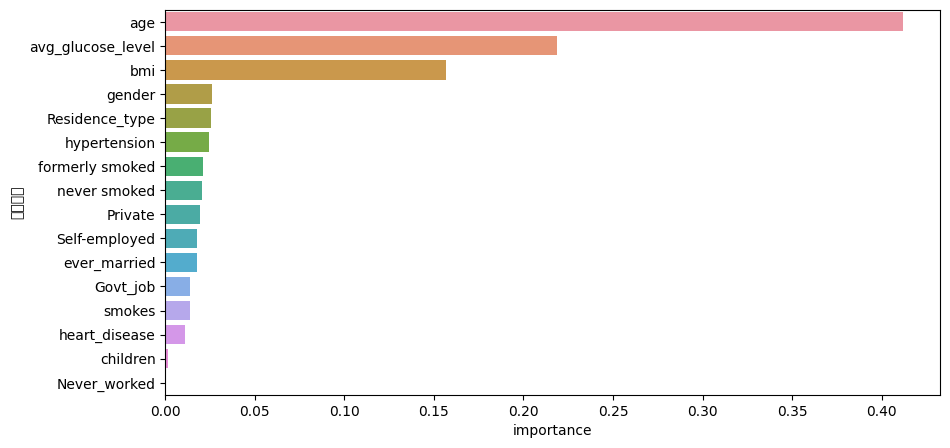

In [ ]:
# 뇌졸중에 가장 영향을 많이주는 독립변수를 순서대로 나열
plt.figure(figsize=(10,5))
sns.barplot(data = df,
            x="importance", y="독립변수",
            orient="h",
            order=df.sort_values(by="importance",ascending=False)["독립변수"])
plt.show()

- 특징들 간에 상관계수 분석해서 다중 공산성 피하기
- 랜덤포레스트 모델 파라미터를 위같이 설정한 이유 설명할 수 있어야됨
- 어떤 나이대가 뇌졸중 확률이 가장 높은지
- 혈당지수,bmi 높을수록 뇌졸중 확률이 높은건지 
- 거주지/ 도시,시골 중에 어떤게 뇌졸중 확률이 높은지
- 남성/여성 중에 어떤게 뇌졸중 확률이 높은지
- 최적화
- 분석을 끝냈다면 어떤 결론을 내리고 어떤 해결책을 실시할건지